In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

# Load feature matrix
X = pd.read_csv('../data/processed/clustering_feature_matrix.csv')

# Load buyer profile
buyer_profile = pd.read_csv('../data/processed/buyer_profile_dataset.csv')

print(X.shape)
X.head()

(855, 13)


,age,satisfaction_score,total_properties_owned,total_investment_value,average_property_value,average_floor_area,client_type_corp,investment_purpose,loan_flag,investment_intensity,portfolio_size_score,investment_density,engagement_score
0,0.158469,0.695625,0.438277,-0.057429,-0.536014,-0.756269,0.0,-0.673856,1.296245,-0.536014,-0.057429,0.648616,0.830775
1,0.681825,0.695625,1.679095,1.158342,-0.245256,-0.426312,0.0,-0.673856,1.296245,-0.245256,1.158342,1.858588,1.508878
2,0.798126,-0.023552,1.679095,0.726419,-0.661136,-0.730908,0.0,-0.673856,1.296245,-0.661136,0.726419,1.698257,0.661249
3,-0.248586,1.414802,1.679095,1.625587,0.204633,0.674068,0.0,1.483997,-0.771459,0.204633,1.625587,1.157318,2.356506
4,0.507373,-1.461906,1.679095,2.569368,1.113357,1.126304,0.0,-0.673856,1.296245,1.113357,2.569368,1.668134,-1.034008


In [3]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X)
    inertia.append(model.inertia_)

elbow_df = pd.DataFrame({
    'K': list(k_values),
    'Inertia': inertia
})

fig = px.line(
    elbow_df,
    x='K',
    y='Inertia',
    markers=True,
    title='Elbow Method for Optimal Number of Clusters'
)

fig.update_layout(template='plotly_white')
fig.show()

In [4]:
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    'K': list(k_values),
    'Silhouette Score': silhouette_scores
})

fig = px.line(
    silhouette_df,
    x='K',
    y='Silhouette Score',
    markers=True,
    title='Silhouette Score by Number of Clusters'
)

fig.update_layout(template='plotly_white')
fig.show()

silhouette_df

,K,Silhouette Score
0,2,0.212810
1,3,0.224781
2,4,0.177906
3,5,0.168647
4,6,0.152404
5,7,0.162284
6,8,0.155025
7,9,0.150806
8,10,0.155235


In [5]:
optimal_k = silhouette_df.loc[
    silhouette_df['Silhouette Score'].idxmax(),
    'K'
]

optimal_k = int(optimal_k)

print('Optimal K:', optimal_k)

Optimal K: 3


In [6]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

buyer_profile['cluster'] = clusters

buyer_profile['cluster'].value_counts()

cluster
1    443
2    391
0     21
Name: count, dtype: int64

In [7]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(X)

pca_df = pd.DataFrame({
    'PC1': pca_components[:, 0],
    'PC2': pca_components[:, 1],
    'Cluster': buyer_profile['cluster'].astype(str)
})

fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    title='Buyer Segments Visualized Using PCA',
    opacity=0.8
)

fig.update_layout(template='plotly_white')
fig.show()

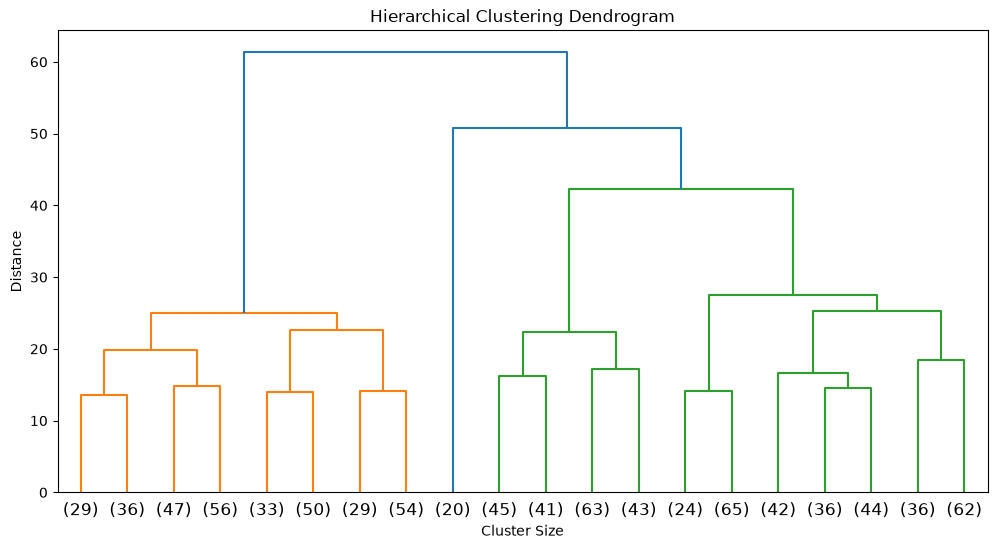

In [8]:
linkage_matrix = linkage(
    X,
    method='ward'
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=20
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

In [9]:
cluster_profile = buyer_profile.groupby('cluster').agg({
    'age': 'mean',
    'satisfaction_score': 'mean',
    'total_properties_owned': 'mean',
    'total_investment_value': 'mean',
    'average_property_value': 'mean',
    'average_floor_area': 'mean'
}).round(2)

cluster_profile

,age,satisfaction_score,total_properties_owned,total_investment_value,average_property_value,average_floor_area
cluster,,,,,,
0,68.90,3.43,7.24,2427906.57,337950.10,1108.30
1,55.41,2.91,3.52,1041505.82,297296.50,989.33
2,54.39,3.15,3.59,1458718.84,409634.08,1343.04


In [10]:
segment_names = {
    0: 'First-Time Buyers',
    1: 'Corporate Investors',
    2: 'Global Investors',
    3: 'Luxury Investors'
}

buyer_profile['buyer_segment'] = (
    buyer_profile['cluster']
    .map(segment_names)
    .fillna('Diversified Investors')
)

buyer_profile[['client_id', 'cluster', 'buyer_segment']].head()

,client_id,cluster,buyer_segment
0,C0001,1,Corporate Investors
1,C0003,2,Global Investors
2,C0006,1,Corporate Investors
3,C0009,2,Global Investors
4,C0013,2,Global Investors


In [11]:
segment_counts = (
    buyer_profile['buyer_segment']
    .value_counts()
    .reset_index()
)

segment_counts.columns = ['Buyer Segment', 'Buyers']

fig = px.bar(
    segment_counts,
    x='Buyer Segment',
    y='Buyers',
    color='Buyer Segment',
    text='Buyers',
    title='Distribution of Buyer Segments'
)

fig.update_layout(template='plotly_white')
fig.show()

In [12]:
buyer_profile.to_csv(
    '../data/processed/buyer_segmented_dataset.csv',
    index=False
)

print('Clustered dataset saved successfully.')

buyer_profile.shape

Clustered dataset saved successfully.


(855, 16)

## Cluster Interpretation

### First-Time Buyers

- Younger age
- Loan dependent
- Personal-use purchases
- Smaller property portfolios

### Corporate Investors

- Corporate clients
- Multiple property ownership
- High investment value

### Global Investors

- Investment-focused
- International presence
- Large transaction values

### Luxury Investors

- High-value properties
- Premium investment behavior
- High satisfaction levels

These segments provide actionable intelligence for targeted marketing, financing strategies, and property recommendation systems.